### Purpose
Trying out 3 different other methods with the background subtraction (before this, temporal subtraction with just 1 frame worked the best) 
- taking the minimum pixle value for multiple frame on 8/29, averaging the, and subtracting that out again
- look the intensity slice line plots, average the intensities on the edges of the line plots and subtract that value out 
- try manually adjusting the contrast of the background and subtracting that out

Notes:
Keeping everything at 200km altitude projection

### Imports

In [2]:
from datetime import datetime, timedelta
import pandas as pd
import numpy as np
import xarray as xr

#for dealing with files:
import os
import re
from scipy.io import readsav
import h5py
import requests
from bs4 import BeautifulSoup
from tqdm import tqdm
from urllib.parse import urljoin, urlparse
import time

#for plotting (the rcParams updates are my personal perference to change font and increase fontsize)
import matplotlib.pyplot as plt
import matplotlib
from matplotlib.colors import ListedColormap
matplotlib.rcParams['mathtext.fontset'] = 'custom'
matplotlib.rcParams['mathtext.fontset'] = 'stix'
matplotlib.rcParams['font.family'] = 'STIXGeneral'
plt.rcParams.update({'font.size': 24,\
                     'xtick.labelsize' : 24,\
                     'ytick.labelsize' : 24,\
                     'axes.titlesize' : 24,\
                     'axes.labelsize' : 24,\
                     'date.autoformatter.minute': '%H:%M' })

import skymap_data_helper # all helper functions for downloading and parsing data
import cv2 # for contrast adjustment
from PIL import Image # for resolution increase
import importlib
importlib.reload(skymap_data_helper)
import math

from scipy.interpolate import griddata
from scipy.stats import pearsonr
from PIL import Image
from scipy.stats import pearsonr # correlation

import os # folder stuff 

import threading
import time 

from concurrent.futures import ProcessPoolExecutor, ThreadPoolExecutor, as_completed
from functools import partial
from tqdm.notebook import tqdm # since in jupyter

import altitude_helper
import importlib
importlib.reload(altitude_helper)

from skimage.metrics import peak_signal_noise_ratio as psnr

import scipy.ndimage # needed for median_filter func, which calculates the running median 

### Load Data

In [4]:
#load an hour of data
site_yknf = 'yknf'
site_fsmi = 'fsmi'
date = datetime(2024,8,30)
hour = 5 #this is in UT
time_index = 251

rgb_asi_skymap_lookup_df = skymap_data_helper.build_rgb_asi_skymap_lookup_table(directory='./trex-rgb-asi_data') #CHANGE TO YOUR SKYMAP DIRECTORY!
yknf_rgb_asi_ds = skymap_data_helper.load_rgb_asi_hour_to_xarray(site_yknf, date, hour, rgb_asi_skymap_lookup_df,data_dir='./trex-rgb-asi_data', skymap_dir='./trex-rgb-asi_data') #CHANGE DIRECTORIES!
fsmi_rgb_asi_ds = skymap_data_helper.load_rgb_asi_hour_to_xarray(site_fsmi, date, hour, rgb_asi_skymap_lookup_df,data_dir='./trex-rgb-asi_data', skymap_dir='./trex-rgb-asi_data') #CHANGE DIRECTORIES!


/home/molidae/Desktop/berkeley/STEVE2.0/skymap_data_helper.py:273: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["valid_end"] = df["valid_end"].fillna(pd.to_datetime(datetime.utcnow().date()))  # today at midnight UTC


Skymap file:
rgb_skymap_yknf_20240829-%2B_v01.sav
skymap path:
./trex-rgb-asi_data/rgb_skymap_yknf_20240829-%2B_v01.sav
Skymap file:
rgb_skymap_fsmi_20240808-%2B_v01.sav
skymap path:
./trex-rgb-asi_data/rgb_skymap_fsmi_20240808-%2B_v01.sav


### Basic Projection Stuff

In [32]:
H_REF = 200000

lat_cam_yknf = yknf_rgb_asi_ds.attrs["site_latitude"]
lon_cam_yknf = yknf_rgb_asi_ds.attrs["site_longitude"]
full_elevation_yknf = yknf_rgb_asi_ds["elevation"]
full_azimuth_yknf = yknf_rgb_asi_ds["azimuth"]

yknf_lat_proj_arr, yknf_lon_proj_arr = altitude_helper.new_spherical_project_lat_lon(
    full_azimuth_yknf, full_elevation_yknf,
    lat_cam_yknf, lon_cam_yknf,
    H_REF
)

rgb_yknf, _ = altitude_helper.mod_plot_lat_lon(yknf_rgb_asi_ds, fsmi_rgb_asi_ds, time_index, "yknf", "fsmi", _, _, _, _, H_REF)

yknf_lon_min = np.nanmin(yknf_lon_ref)
yknf_lon_max = np.nanmax(yknf_lon_ref)
yknf_lat_min = np.nanmin(yknf_lat_ref)
yknf_lat_max = np.nanmax(yknf_lat_ref)

# above and below these thresholds, average the "background" and subtract it from the entire image
yknf_lat_min_cutoff = 61.5
yknf_lat_max_cutoff = 63.5



In [54]:
def get_rgb_intensity_slice(lat_proj, lon_proj, rgb, 
                         lat_min, lat_max, 
                         site_name, time_index, 
                         lon):

    """
    Given projected latitude and longitude arrays and a particular longitude to slice at, find the intensities for the
    latitudes along this longitude slice  (in 0.5 degree intervals, common across both cameras). Changed for interpolatiing over all 3 color channels. 
    
    input:
        lat_proj = 2D projected latitude arr (output of project_lat_lon())
        lon_proj = 2D projected longitude arr (output of project_lat_lon())
        lat_min = minimum latitude that both cameras see
        lat_max = maximum latitude that both cameras see 
        rgb = 3D rgb array (output of plot_lat_lon()) 
        time_index = for naming purposes 
        lon_to_slice = longitude we should make a slice at/make plot for 
        h = altitude projected to, corresponding to 
    
    output:
        R_lat = keys:latitude, values:brightness at that latitude --> across 1 longitude slice (lon_slice), move across different latitudes and store the pixel brightness at that latitude 
    """

    #print(f"Interpolating at longitude: {lon_to_slice}\n")

    #------------get the pixels within +-1 degree longitude------------#
    #------also create array of latitudes to sample brightness over------#
    lat_grid = np.arange(lat_min, lat_max, 0.5) # this is about close to the actual pixel resolution? decrease it
    slice_mask = np.abs(lon_proj - lon_to_slice) <= 1
    lat_slice = lat_proj[slice_mask]
    R_slice = rgb[:,:, 0][slice_mask]
    G_slice = rgb[:,:, 1][slice_mask]
    B_slice = rgb[:,:, 2][slice_mask]
    
    #------interpolate onto regular spaced lat_grid----------#
    interp_locations = np.column_stack((np.full_like(lat_grid, lon_to_slice), lat_grid))
    points = np.column_stack((lon_proj[slice_mask], lat_proj[slice_mask])) # flatten points for interpolation
    values_R = R_slice.flatten()
    values_G = G_slice.flatten()
    values_B = B_slice.flatten()
    
    # only interpolate if enough points
    if len(points) >= 3:
        R_intensity_interp = griddata(points, values_R, interp_locations, method='linear')
        G_intensity_interp = griddata(points, values_G, interp_locations, method='linear')
        B_intensity_interp = griddata(points, values_B, interp_locations, method='linear')
    else:
        R_intensity_interp = np.full(len(lat_grid), np.nan)
        G_intensity_interp = np.full(len(lat_grid), np.nan)
        B_intensity_interp = np.full(len(lat_grid), np.nan)

    return lat_grid, R_intensity_interp, G_intensity_interp, B_intensity_interp

In [99]:
def mod_plot_lat_lon(yknf_rgb_asi_ds, time_index):
    ''' 
    Returns the contrast-adjusted rgb arrays for yknf and fsmi--> no actual plotting lol 
    
    Parameters:
        yknf_rgb_asi_ds: xarray of the yknf skymap <xarray>
        fsmi_rgb_asi_ds: xarray of the fsmi skymap <xarray>
        time_index: specific frame we are looking at from the asi ds <int>
        site_name_yknf: string to label the plots
        site_name_fsmi: string to label the plots
        yknf_lat: projected latitude array of one yknf frame <2d arr>
        yknf_lon: projected longitude array of one yknf frame <2d arr>
        fsmi_lat: projected latitude array of one fsmi frame <2d arr>
        fsmi_lon: projected longitude array of one fsmi frame <2d arr>
        h_target: height that yknf & fsmi frames were projected to <int>
        lat_lon_plots: folder to save the 3 images to 

    Outputs:
        3 plots of the YKNF, FSMI, overlaid latitude and longitude
    '''    
    
    R_yknf = yknf_rgb_asi_ds_ref.image.sel(channel="R").isel(times=time_index).values
    G_yknf = yknf_rgb_asi_ds_ref.image.sel(channel="G").isel(times=time_index).values
    B_yknf = yknf_rgb_asi_ds_ref.image.sel(channel="B").isel(times=time_index).values
    
    # Extract time and format it
    raw_time = yknf_rgb_asi_ds.times.values[time_index]
    time_obj = pd.to_datetime(raw_time.decode("utf-8").replace(" UTC", ""))
    time_str = time_obj.strftime("%b. %d, %Y %H:%M:%S UT")
        
    # contrast adjustment: alpha=contrast, beta=brightness --> dont need any now!
    alpha = 1
    beta = 0
    rgb_yknf = np.stack([R_yknf, G_yknf, B_yknf], axis=-1)  # shape: (x, y, 3)
    
    rgb_yknf_adjusted = cv2.convertScaleAbs(rgb_yknf, alpha=alpha, beta=beta)

    raw_time = yknf_rgb_asi_ds.times.values[time_index]
    print(f"The R,G,B values currently in memory are from: {raw_time}")
    
    return rgb_yknf_adjusted

### Averaged Temporal Subtraction
Loop through all of the different longitude slices, make sure get the intensity profiles, mask them where there is no aurora, and then subtract those values out. 
Do this for just YKNF first. 

In [65]:
lat_step = 0.5
lon_to_slice_arr = np.arange(yknf_lon_min, yknf_lon_max, lat_step)

# store each slice after background is subtracted 
R_correct_arr = []
R_bg_arr = []
G_correct_arr = []
G_bg_arr = []
B_correct_arr = []
B_bg_arr = []

for lon_to_slice in lon_to_slice_arr: 
    yknf_lat_grid, yknf_R_intensity_interp, yknf_G_intensity_interp, yknf_B_intensity_interp = get_rgb_intensity_slice(yknf_lat_proj_arr, yknf_lon_proj_arr, rgb_yknf,
                                                                                                                        yknf_lat_min, yknf_lat_max,
                                                                                                                        "YKNF", time_index, 
                                                                                                                        lon_to_slice)

    # removing the background
    background_mask = (yknf_lat_grid < yknf_lat_min_cutoff) | (yknf_lat_grid > yknf_lat_max_cutoff)
    
    R_background_intensities = yknf_R_intensity_interp[background_mask].copy()
    R_background_intensities = R_background_intensities[~np.isnan(R_background_intensities)]
    
    G_background_intensities = yknf_G_intensity_interp[background_mask].copy()
    G_background_intensities = G_background_intensities[~np.isnan(G_background_intensities)]
    
    B_background_intensities = yknf_B_intensity_interp[background_mask].copy()
    B_background_intensities = B_background_intensities[~np.isnan(B_background_intensities)]

    if len(R_background_intensities) > 0:
      #  print(f"len R background_intensities: {len(R_background_intensities)}")
        R_bg_floor = np.mean(R_background_intensities)
        yknf_R_intensity_corrected = yknf_R_intensity_interp - R_bg_floor
        yknf_R_intensity_corrected = np.maximum(yknf_R_intensity_corrected, 0) # prevent clipping 
        R_correct_arr.append(yknf_R_intensity_corrected)
        R_bg_arr.append(R_bg_floor)
    else:
       # print("[R] No background pixels found within the specified cutoffs!")
        R_correct_arr.append(yknf_R_intensity_interp)

    if len(G_background_intensities) > 0:
       # print(f"len G background_intensities: {len(G_background_intensities)}")
        G_bg_floor = np.mean(G_background_intensities)
        yknf_G_intensity_corrected = yknf_G_intensity_interp - G_bg_floor
        yknf_G_intensity_corrected = np.maximum(yknf_G_intensity_corrected, 0) # prevent clipping 
        G_correct_arr.append(yknf_G_intensity_corrected)
        G_bg_arr.append(G_bg_floor)
    else:
        #print("[G] No background pixels found within the specified cutoffs!")
        G_correct_arr.append(yknf_G_intensity_interp)
    
    if len(B_background_intensities) > 0:
       # print(f"len B background_intensities: {len(B_background_intensities)}")
        B_bg_floor = np.mean(B_background_intensities)
        yknf_B_intensity_corrected = yknf_B_intensity_interp - B_bg_floor
        yknf_B_intensity_corrected = np.maximum(yknf_B_intensity_corrected, 0) # prevent clipping 
        B_correct_arr.append(yknf_B_intensity_corrected)
        B_bg_arr.append(B_bg_floor)
    else:
        #print("[B] No background pixels found within the specified cutoffs!")
        B_correct_arr.append(yknf_B_intensity_interp)

    
R_final = np.array(R_correct_arr).T
G_final = np.array(G_correct_arr).T
B_final = np.array(B_correct_arr).T
final_rgb = np.stack([R_final, G_final, B_final], axis=-1)

final_R_bg = np.array(R_bg_arr).T
final_G_bg = np.array(G_bg_arr).T
final_B_bg = np.array(B_bg_arr).T

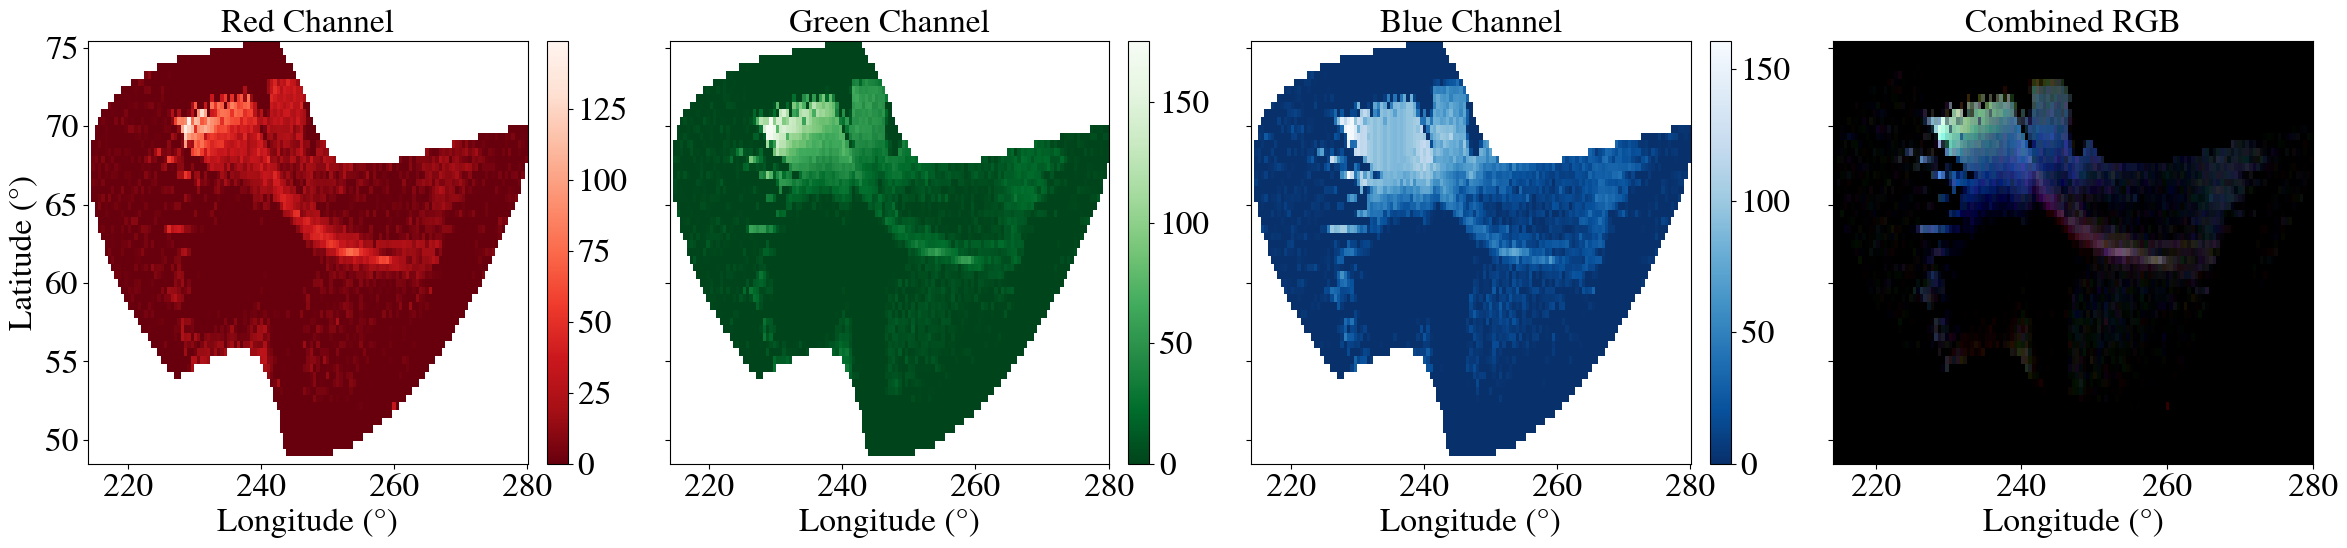

In [66]:
# 1.normalize rgb to 0.0 - 1.0), same for everything --> limit longitudes and see how it improves the altitude calculations
vmax = np.nanmax(final_rgb)
rgb_display = np.nan_to_num(final_rgb / vmax)

fig, axes = plt.subplots(1, 4, figsize=(24, 6), sharey=True)

# common plotting bounds 
img_extent = [lon_to_slice_arr.min(), lon_to_slice_arr.max(), 
              yknf_lat_grid.min(), yknf_lat_grid.max()]

# --- RED  ---
im0 = axes[0].imshow(R_final, origin='lower', aspect='auto', extent=img_extent, cmap='Reds_r')
axes[0].set_title("Red Channel")
axes[0].set_ylabel("Latitude (°)")
plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

# --- GREEN  ---
im1 = axes[1].imshow(G_final, origin='lower', aspect='auto', extent=img_extent, cmap='Greens_r')
axes[1].set_title("Green Channel")
plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

# --- BLUE  ---
im2 = axes[2].imshow(B_final, origin='lower', aspect='auto', extent=img_extent, cmap='Blues_r')
axes[2].set_title("Blue Channel")
plt.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04)

# --- RGB  ---
# dont need cmap for rgb 
axes[3].imshow(rgb_display, origin='lower', aspect='auto', extent=img_extent)
axes[3].set_title("Combined RGB")

# format
for ax in axes:
    ax.set_xlabel("Longitude (°)")

plt.tight_layout()
plt.show()

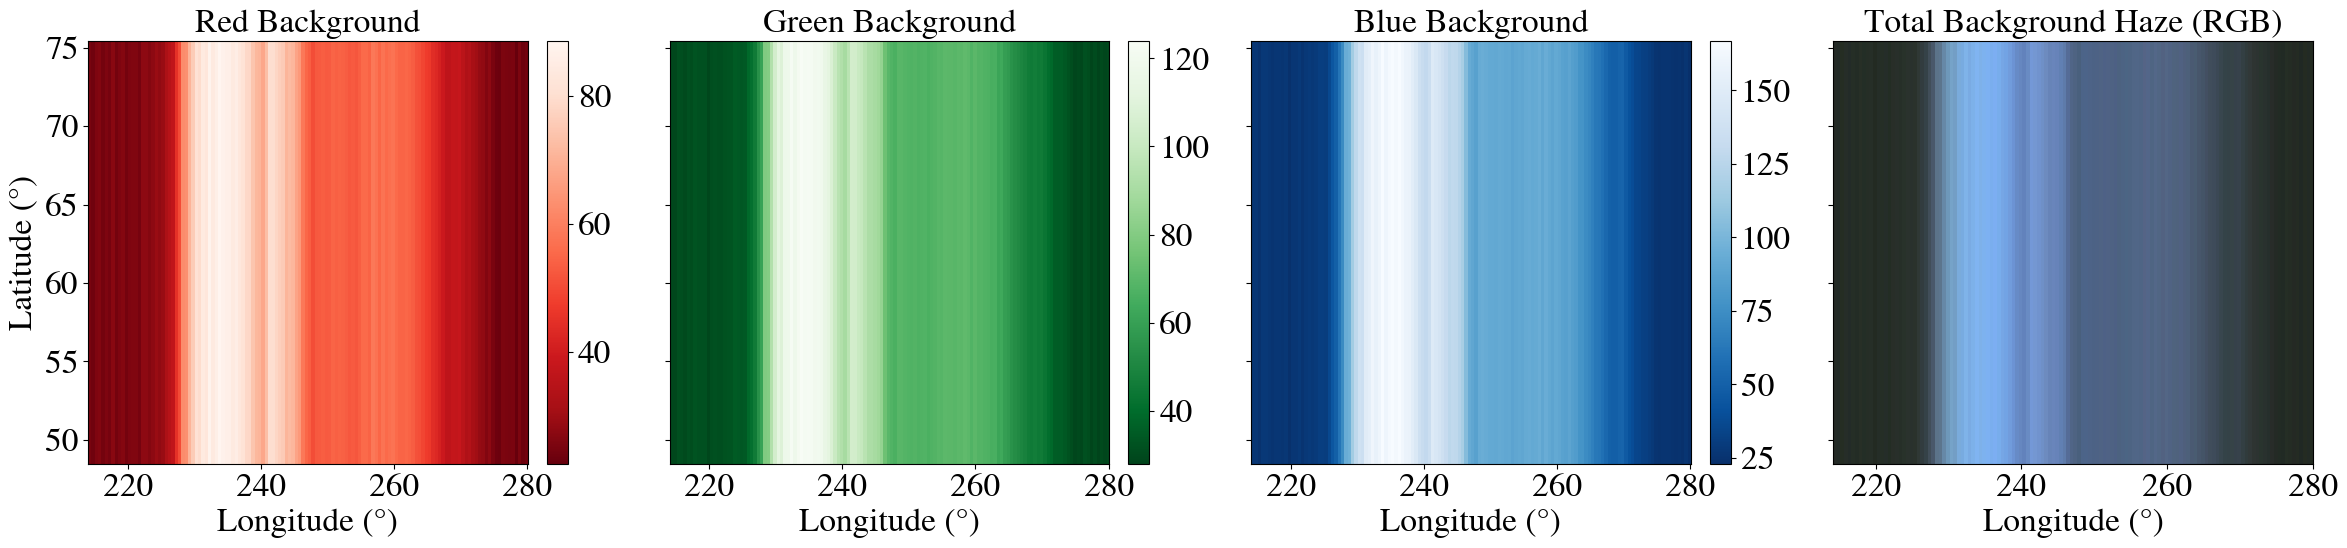

In [67]:
# grid where every row is a copy of your median array
# Shape will be (len(yknf_lat_grid), len(lon_to_slice_arr))
R_bg_map = np.tile(R_bg_arr, (len(yknf_lat_grid), 1))
G_bg_map = np.tile(G_bg_arr, (len(yknf_lat_grid), 1))
B_bg_map = np.tile(B_bg_arr, (len(yknf_lat_grid), 1))

bg_rgb_combined = np.stack([R_bg_map, G_bg_map, B_bg_map], axis=-1)

# normalize for the RGB display
#  scale it by the max value of your CORRECTED image 
# so the brightness is relative to the aurora we see
vmax = np.nanmax(final_rgb)
bg_rgb_display = np.nan_to_num(bg_rgb_combined / vmax)

fig, axes = plt.subplots(1, 4, figsize=(24, 6), sharey=True)
img_extent = [lon_to_slice_arr.min(), lon_to_slice_arr.max(), 
              yknf_lat_grid.min(), yknf_lat_grid.max()]

# plot each channel with its respective colormap
maps = [R_bg_map, G_bg_map, B_bg_map]
cmaps = ['Reds_r', 'Greens_r', 'Blues_r']
titles = ['Red Background', 'Green Background', 'Blue Background']

for i in range(3):
    im = axes[i].imshow(maps[i], origin='lower', aspect='auto', extent=img_extent, cmap=cmaps[i])
    axes[i].set_title(titles[i])
    axes[i].set_xlabel("Longitude (°)")
    plt.colorbar(im, ax=axes[i], fraction=0.046, pad=0.04)

axes[0].set_ylabel("Latitude (°)")

# Plotting the RGB combined background
axes[3].imshow(bg_rgb_display, origin='lower', aspect='auto', extent=img_extent)
axes[3].set_title("Total Background Haze (RGB)")
axes[3].set_xlabel("Longitude (°)")

plt.tight_layout()
plt.show()

### Averaging many frames over time
- time_index just for getting RGBs
- look at multiple frames that night and see what the minimum value might be for another day around the same time when its clear
- average over 30 frames

In [3]:
#load an hour of data for day before: 8/29
site_yknf = 'yknf'
date = datetime(2024,9,5) # is clear around 5:12 UT so good for background subtraction 
hour = 5 #this is in UT
time_index = 251  # 05:12:33 UT
test_dir = './trex-rgb-asi_data' #CHANGE THIS BASED ON WHERE YOU WANT TO PUT THE DATA!

skymap_data_helper.download_trex_rgb_asi_files(date,'yknf',test_dir)
rgb_asi_skymap_lookup_df = skymap_data_helper.build_rgb_asi_skymap_lookup_table(directory='./trex-rgb-asi_data') #CHANGE TO YOUR SKYMAP DIRECTORY!
yknf_rgb_asi_ds_ref = skymap_data_helper.load_rgb_asi_hour_to_xarray(site_yknf, date, hour, rgb_asi_skymap_lookup_df,data_dir='./trex-rgb-asi_data', skymap_dir='./trex-rgb-asi_data') #CHANGE DIRECTORIES!



Accessing https://data.phys.ucalgary.ca/sort_by_project/TREx/RGB/stream0/2024/09/05/...


YKNF ut04: 100%|█████████████████████████████| 37/37 [00:00<00:00, 41383.80it/s]


YKNF ut05: 100%|█████████████████████████████| 60/60 [00:00<00:00, 19532.62it/s]


YKNF ut06: 100%|█████████████████████████████| 60/60 [00:00<00:00, 19779.79it/s]


YKNF ut07: 100%|█████████████████████████████| 60/60 [00:00<00:00, 18660.70it/s]


YKNF ut08: 100%|████████████████████████████████| 60/60 [03:02<00:00,  3.04s/it]


YKNF ut09: 100%|████████████████████████████████| 60/60 [04:52<00:00,  4.87s/it]


YKNF ut10: 100%|████████████████████████████████| 51/51 [04:36<00:00,  5.42s/it]
/home/molidae/Desktop/berkeley/STEVE2.0/skymap_data_helper.py:273: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["valid_end"] = df["valid_end"].fillna(pd.to_datetime(datetime.utcnow().date()))  # today at midnight UTC


Skymap file:
rgb_skymap_yknf_20240829-%2B_v01.sav
skymap path:
./trex-rgb-asi_data/rgb_skymap_yknf_20240829-%2B_v01.sav


In [88]:
rgb_asi_skymap_lookup_df = skymap_data_helper.build_rgb_asi_skymap_lookup_table(directory='./trex-rgb-asi_data') #CHANGE TO YOUR SKYMAP DIRECTORY!
yknf_rgb_asi_ds_ref = skymap_data_helper.load_rgb_asi_hour_to_xarray(site_yknf, datetime(2024,9,5), 5, rgb_asi_skymap_lookup_df,data_dir='./trex-rgb-asi_data', skymap_dir='./trex-rgb-asi_data') #CHANGE DIRECTORIES!


/home/molidae/Desktop/berkeley/STEVE2.0/skymap_data_helper.py:273: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["valid_end"] = df["valid_end"].fillna(pd.to_datetime(datetime.utcnow().date()))  # today at midnight UTC


Skymap file:
rgb_skymap_yknf_20240829-%2B_v01.sav
skymap path:
./trex-rgb-asi_data/rgb_skymap_yknf_20240829-%2B_v01.sav


In [101]:
raw_time = yknf_rgb_asi_ds.times.values[251]
time_obj = pd.to_datetime(raw_time.decode("utf-8").replace(" UTC", ""))
time_str = time_obj.strftime("%b. %d, %Y %H:%M:%S UT")

In [102]:
rgb_og = mod_plot_lat_lon(yknf_rgb_asi_ds, 251)

The R,G,B values currently in memory are from: b'2024-08-30 05:12:33.021053 UTC'


The R,G,B values currently in memory are from: b'2024-09-05 05:12:21.095689 UTC'
The R,G,B values currently in memory are from: b'2024-09-05 05:12:24.295707 UTC'
The R,G,B values currently in memory are from: b'2024-09-05 05:12:27.178368 UTC'
The R,G,B values currently in memory are from: b'2024-09-05 05:12:30.055784 UTC'
The R,G,B values currently in memory are from: b'2024-09-05 05:12:33.255809 UTC'
The R,G,B values currently in memory are from: b'2024-09-05 05:12:36.135874 UTC'
The R,G,B values currently in memory are from: b'2024-09-05 05:12:39.015897 UTC'
[np.float64(8.887738597548724), np.float64(8.884550180831827), np.float64(8.888868796463733), np.float64(8.893873066104078), np.float64(8.882778280088406), np.float64(8.893383313240909), np.float64(8.856622965641954)]


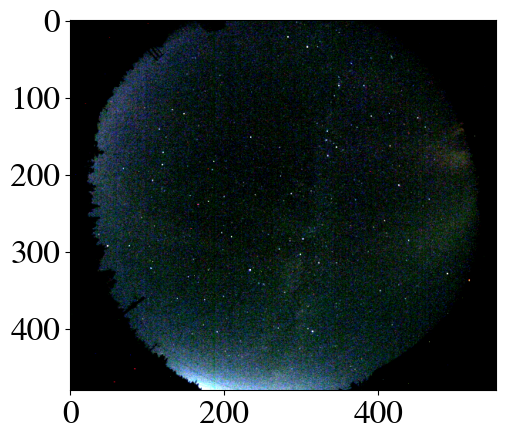

In [108]:
time_idx_arr = [247, 248, 249, 250, 251, 252, 253] # average over 7 frames
min_intensity_arr = []

for time_idx in time_idx_arr:
    rgb_ref= mod_plot_lat_lon(yknf_rgb_asi_ds_ref, time_idx)
    
    rgb_ref = np.array(rgb_ref)
    min_intensity = np.mean(rgb_ref)
    min_intensity_arr.append(min_intensity)

avg_intensity = np.average(min_intensity_arr)

# cvt to float before subtracting
rgb_background = np.full_like(rgb_og, avg_intensity, dtype=float)
rgb_bg_subtract = rgb_og.astype(float) - rgb_background

alpha = 15  
stretched_data = rgb_bg_subtract * alpha

# clipping
final_image = np.clip(stretched_data, 0, 255).astype(np.uint8)

plt.imshow(final_image)
print(min_intensity_arr)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [8.883973599988519..8.883973599988519].


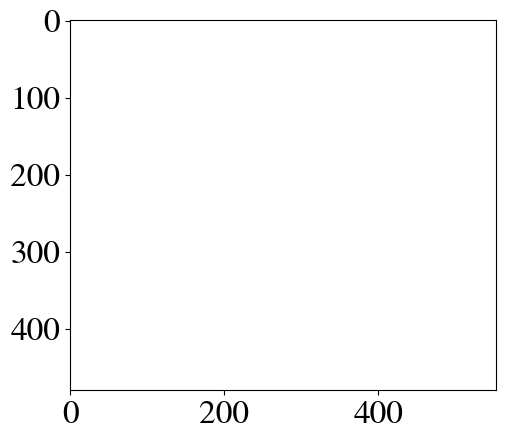

In [107]:
plt.imshow(rgb_background)